In [1]:
print("AeroPure kernel is working!")

AeroPure kernel is working!


In [2]:
# ============================================================
# W4 CELL 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("W4 libraries imported successfully.")

W4 libraries imported successfully.


In [3]:
# ============================================================
# W4 CELL 2 — LOAD DATASET
# ============================================================

df = pd.read_csv(
    "../dataset kaggle/city_day.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    ["City", "Date"]
).reset_index(drop=True)

print("=" * 70)
print("W4 DATASET")
print("=" * 70)

print("Shape:", df.shape)

display(
    df[
        ["City", "Date", "AQI", "AQI_Bucket"]
    ].head()
)

W4 DATASET
Shape: (29531, 16)


,City,Date,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN


In [4]:
# ============================================================
# W4 CELL 3 — CREATE TOMORROW AQI
# ============================================================

df["Tomorrow_AQI"] = (
    df.groupby("City")["AQI"].shift(-1)
)

df["Next_Date"] = (
    df.groupby("City")["Date"].shift(-1)
)

df["Days_To_Next"] = (
    df["Next_Date"] - df["Date"]
).dt.days

print("=" * 70)
print("TOMORROW AQI TARGET")
print("=" * 70)

print(
    "Rows with next-day record:",
    (df["Days_To_Next"] == 1).sum()
)

print(
    "Missing Tomorrow_AQI:",
    df["Tomorrow_AQI"].isna().sum()
)

TOMORROW AQI TARGET
Rows with next-day record: 29505
Missing Tomorrow_AQI: 4682


In [5]:
# ============================================================
# W4 CELL 4 — CLEAN TOMORROW AQI
# ============================================================

df = df[
    df["Days_To_Next"] == 1
].copy()

df = df.dropna(
    subset=["Tomorrow_AQI"]
).copy()

df = df.drop(
    columns=[
        "Next_Date",
        "Days_To_Next"
    ]
)

df = df.reset_index(drop=True)

print("=" * 70)
print("CLEAN TOMORROW AQI DATA")
print("=" * 70)

print("Rows:", len(df))

print(
    "Missing Tomorrow_AQI:",
    df["Tomorrow_AQI"].isna().sum()
)

display(
    df[
        ["City", "Date", "AQI", "Tomorrow_AQI"]
    ].head(10)
)

CLEAN TOMORROW AQI DATA
Rows: 24849
Missing Tomorrow_AQI: 0


,City,Date,AQI,Tomorrow_AQI
0,Ahmedabad,2015-01-28,NaN,209.0
1,Ahmedabad,2015-01-29,209.0,328.0
2,Ahmedabad,2015-01-30,328.0,514.0
3,Ahmedabad,2015-01-31,514.0,782.0
4,Ahmedabad,2015-02-01,782.0,914.0
5,Ahmedabad,2015-02-02,914.0,660.0
6,Ahmedabad,2015-02-03,660.0,294.0
7,Ahmedabad,2015-02-04,294.0,149.0
8,Ahmedabad,2015-02-05,149.0,190.0
9,Ahmedabad,2015-02-06,190.0,247.0


In [6]:
# ============================================================
# W4 CELL 5 — FEATURES
# ============================================================

features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene"
]

target = "Tomorrow_AQI"

print("=" * 70)
print("W4 FEATURES")
print("=" * 70)

print("Number of features:", len(features))

for feature in features:
    print("-", feature)

print("\nTarget:", target)

W4 FEATURES
Number of features: 11
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene

Target: Tomorrow_AQI


In [7]:
# ============================================================
# W4 CELL 6 — TIME-BASED TRAIN / TEST SPLIT
# ============================================================

df = df.sort_values(
    ["Date", "City"]
).reset_index(drop=True)

unique_dates = sorted(
    df["Date"].unique()
)

split_index = int(
    len(unique_dates) * 0.80
)

split_date = unique_dates[split_index]

train_df = df[
    df["Date"] < split_date
].copy()

test_df = df[
    df["Date"] >= split_date
].copy()

print("=" * 70)
print("W4 TIME-BASED SPLIT")
print("=" * 70)

print("Split date:", split_date)

print("\nTotal rows:", len(df))
print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

print("\nTraining period:")
print(
    train_df["Date"].min(),
    "to",
    train_df["Date"].max()
)

print("\nTesting period:")
print(
    test_df["Date"].min(),
    "to",
    test_df["Date"].max()
)

common_dates = set(
    train_df["Date"]
).intersection(
    set(test_df["Date"])
)

print("\nCommon dates:", len(common_dates))

W4 TIME-BASED SPLIT
Split date: 2019-05-26 00:00:00

Total rows: 24849
Train rows: 16017
Test rows : 8832

Training period:
2015-01-01 00:00:00 to 2019-05-25 00:00:00

Testing period:
2019-05-26 00:00:00 to 2020-06-30 00:00:00

Common dates: 0


In [8]:
# ============================================================
# W4 CELL 7 — MISSING VALUE IMPUTATION
# ============================================================

train_imp = train_df.copy()
test_imp = test_df.copy()

for col in features:

    # Calculate city median from TRAINING DATA ONLY
    city_medians = (
        train_imp
        .groupby("City")[col]
        .median()
    )

    # Overall training median
    overall_median = train_imp[col].median()

    # Training data
    train_imp[col] = (
        train_imp[col]
        .fillna(
            train_imp["City"].map(city_medians)
        )
        .fillna(overall_median)
    )

    # Test data uses training-derived medians
    test_imp[col] = (
        test_imp[col]
        .fillna(
            test_imp["City"].map(city_medians)
        )
        .fillna(overall_median)
    )

print("=" * 70)
print("W4 IMPUTATION")
print("=" * 70)

print("\nTRAIN missing values:")
print(train_imp[features].isna().sum())

print("\nTEST missing values:")
print(test_imp[features].isna().sum())

W4 IMPUTATION

TRAIN missing values:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64

TEST missing values:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64


In [9]:
# ============================================================
# W4 CELL 8 — CREATE X AND Y
# ============================================================

X_train = train_imp[features].copy()
X_test = test_imp[features].copy()

y_train = train_imp[target].copy()
y_test = test_imp[target].copy()

print("=" * 70)
print("W4 ML DATASET")
print("=" * 70)

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nMissing target values:")
print("y_train:", y_train.isna().sum())
print("y_test :", y_test.isna().sum())

W4 ML DATASET

X_train: (16017, 11)
X_test : (8832, 11)

y_train: (16017,)
y_test : (8832,)

Missing target values:
y_train: 0
y_test : 0


In [10]:
# ============================================================
# W4 CELL 9 — STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("=" * 70)
print("STANDARDIZATION COMPLETE")
print("=" * 70)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

STANDARDIZATION COMPLETE
X_train_scaled: (16017, 11)
X_test_scaled : (8832, 11)


In [11]:
# ============================================================
# W4 CELL 10 — RIDGE REGRESSION
# ============================================================

ridge_model = Ridge(
    alpha=1.0
)

ridge_model.fit(
    X_train_scaled,
    y_train
)

y_pred_ridge = ridge_model.predict(
    X_test_scaled
)

print("=" * 70)
print("RIDGE REGRESSION")
print("=" * 70)

print("Alpha:", 1.0)
print("Predictions generated:", len(y_pred_ridge))

RIDGE REGRESSION
Alpha: 1.0
Predictions generated: 8832


In [12]:
# ============================================================
# W4 CELL 11 — RIDGE EVALUATION
# ============================================================

ridge_mae = mean_absolute_error(
    y_test,
    y_pred_ridge
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ridge
    )
)

ridge_r2 = r2_score(
    y_test,
    y_pred_ridge
)

print("=" * 70)
print("RIDGE MODEL PERFORMANCE")
print("=" * 70)

print(f"MAE  : {ridge_mae:.4f}")
print(f"RMSE : {ridge_rmse:.4f}")
print(f"R²   : {ridge_r2:.4f}")

RIDGE MODEL PERFORMANCE
MAE  : 25.6951
RMSE : 42.4745
R²   : 0.8331


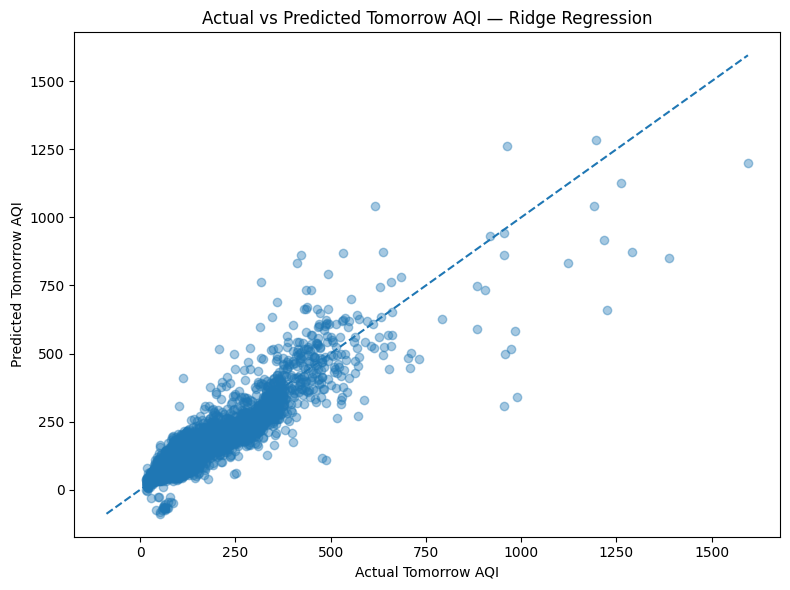

Ridge graph saved successfully.


In [13]:
# ============================================================
# W4 CELL 12 — RIDGE ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_ridge,
    alpha=0.4
)

min_value = min(
    y_test.min(),
    y_pred_ridge.min()
)

max_value = max(
    y_test.max(),
    y_pred_ridge.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Tomorrow AQI")
plt.ylabel("Predicted Tomorrow AQI")

plt.title(
    "Actual vs Predicted Tomorrow AQI — Ridge Regression"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w4_ridge_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Ridge graph saved successfully.")

In [14]:
# ============================================================
# W4 CELL 13 — LASSO REGRESSION
# ============================================================

lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lasso = lasso_model.predict(
    X_test_scaled
)

print("=" * 70)
print("LASSO REGRESSION")
print("=" * 70)

print("Alpha:", 0.01)
print("Predictions generated:", len(y_pred_lasso))

LASSO REGRESSION
Alpha: 0.01
Predictions generated: 8832


In [15]:
# ============================================================
# W4 CELL 14 — LASSO EVALUATION
# ============================================================

lasso_mae = mean_absolute_error(
    y_test,
    y_pred_lasso
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lasso
    )
)

lasso_r2 = r2_score(
    y_test,
    y_pred_lasso
)

print("=" * 70)
print("LASSO MODEL PERFORMANCE")
print("=" * 70)

print(f"MAE  : {lasso_mae:.4f}")
print(f"RMSE : {lasso_rmse:.4f}")
print(f"R²   : {lasso_r2:.4f}")

LASSO MODEL PERFORMANCE
MAE  : 25.6884
RMSE : 42.4599
R²   : 0.8332


In [17]:
# ============================================================
# W4 CELL 15 — OLS BASELINE FOR COMPARISON
# ============================================================

from sklearn.linear_model import LinearRegression

# Create OLS model
ols_model_w4 = LinearRegression()

# Train OLS using the same W4 training data
ols_model_w4.fit(
    X_train_scaled,
    y_train
)

# Predict on the same W4 test data
y_pred_ols_w4 = ols_model_w4.predict(
    X_test_scaled
)

# Calculate metrics
ols_mae_w4 = mean_absolute_error(
    y_test,
    y_pred_ols_w4
)

ols_rmse_w4 = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ols_w4
    )
)

ols_r2_w4 = r2_score(
    y_test,
    y_pred_ols_w4
)

print("=" * 70)
print("W4 OLS BASELINE")
print("=" * 70)

print(f"MAE  : {ols_mae_w4:.4f}")
print(f"RMSE : {ols_rmse_w4:.4f}")
print(f"R²   : {ols_r2_w4:.4f}")

W4 OLS BASELINE
MAE  : 25.6947
RMSE : 42.4752
R²   : 0.8331


In [18]:
# ============================================================
# W4 CELL 16 — OLS VS RIDGE VS LASSO
# ============================================================

regression_comparison = pd.DataFrame({
    "Model": [
        "OLS Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        ols_mae_w4,
        ridge_mae,
        lasso_mae
    ],
    "RMSE": [
        ols_rmse_w4,
        ridge_rmse,
        lasso_rmse
    ],
    "R2": [
        ols_r2_w4,
        ridge_r2,
        lasso_r2
    ]
})

print("=" * 70)
print("W4 REGRESSION MODEL COMPARISON")
print("=" * 70)

display(regression_comparison)

W4 REGRESSION MODEL COMPARISON


,Model,MAE,RMSE,R2
0,OLS Linear Regression,25.694745,42.475218,0.833065
1,Ridge Regression,25.695081,42.474451,0.833072
2,Lasso Regression,25.688423,42.459937,0.833186


In [19]:
# ============================================================
# W4 CELL 17 — SAVE REGRESSION COMPARISON
# ============================================================

regression_comparison.to_csv(
    "../graphs/w4_regression_comparison.csv",
    index=False
)

print("W4 regression comparison saved successfully.")

W4 regression comparison saved successfully.


In [20]:
# ============================================================
# W4 CELL 18 — HAZARDOUS-AIR-DAY TARGET
# ============================================================

HAZARDOUS_THRESHOLD = 301

train_imp["Hazardous_Tomorrow"] = (
    train_imp["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

test_imp["Hazardous_Tomorrow"] = (
    test_imp["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

y_train_cls = train_imp[
    "Hazardous_Tomorrow"
].copy()

y_test_cls = test_imp[
    "Hazardous_Tomorrow"
].copy()

print("=" * 70)
print("HAZARDOUS-AIR-DAY TARGET")
print("=" * 70)

print("Hazardous threshold:", HAZARDOUS_THRESHOLD)

print("\nTRAIN CLASS DISTRIBUTION:")
print(
    y_train_cls.value_counts()
    .sort_index()
)

print("\nTEST CLASS DISTRIBUTION:")
print(
    y_test_cls.value_counts()
    .sort_index()
)

print("\nTRAIN CLASS PERCENTAGES:")
print(
    (y_train_cls.value_counts(normalize=True)
     .sort_index() * 100)
)

HAZARDOUS-AIR-DAY TARGET
Hazardous threshold: 301

TRAIN CLASS DISTRIBUTION:
Hazardous_Tomorrow
0    12949
1     3068
Name: count, dtype: int64

TEST CLASS DISTRIBUTION:
Hazardous_Tomorrow
0    8226
1     606
Name: count, dtype: int64

TRAIN CLASS PERCENTAGES:
Hazardous_Tomorrow
0    80.845352
1    19.154648
Name: proportion, dtype: float64


In [21]:
# ============================================================
# W4 CELL 19 — CLASS BALANCE
# ============================================================

train_class_counts = (
    y_train_cls
    .value_counts()
    .sort_index()
)

test_class_counts = (
    y_test_cls
    .value_counts()
    .sort_index()
)

print("=" * 70)
print("CLASS BALANCE")
print("=" * 70)

print("\nTRAIN:")
print(
    "Non-Hazardous (0):",
    train_class_counts.get(0, 0)
)

print(
    "Hazardous (1):",
    train_class_counts.get(1, 0)
)

print("\nTEST:")
print(
    "Non-Hazardous (0):",
    test_class_counts.get(0, 0)
)

print(
    "Hazardous (1):",
    test_class_counts.get(1, 0)
)

CLASS BALANCE

TRAIN:
Non-Hazardous (0): 12949
Hazardous (1): 3068

TEST:
Non-Hazardous (0): 8226
Hazardous (1): 606


In [22]:
# ============================================================
# W4 CELL 20 — LOGISTIC REGRESSION CLASSIFIER
# ============================================================

logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train_cls
)

# Predicted class
y_pred_cls = logistic_model.predict(
    X_test_scaled
)

# Predicted probability of hazardous class
y_prob_cls = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("=" * 70)
print("LOGISTIC REGRESSION CLASSIFIER")
print("=" * 70)

print("Model trained successfully.")
print("Test predictions:", len(y_pred_cls))

LOGISTIC REGRESSION CLASSIFIER
Model trained successfully.
Test predictions: 8832


In [23]:
# ============================================================
# W4 CELL 21 — CLASSIFICATION EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test_cls,
    y_pred_cls
)

precision = precision_score(
    y_test_cls,
    y_pred_cls,
    zero_division=0
)

recall = recall_score(
    y_test_cls,
    y_pred_cls,
    zero_division=0
)

f1 = f1_score(
    y_test_cls,
    y_pred_cls,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test_cls,
    y_prob_cls
)

print("=" * 70)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 70)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy  : 0.9691
Precision : 0.7063
Recall    : 0.9406
F1 Score  : 0.8068
ROC-AUC   : 0.9912


CONFUSION MATRIX
[[7989  237]
 [  36  570]]


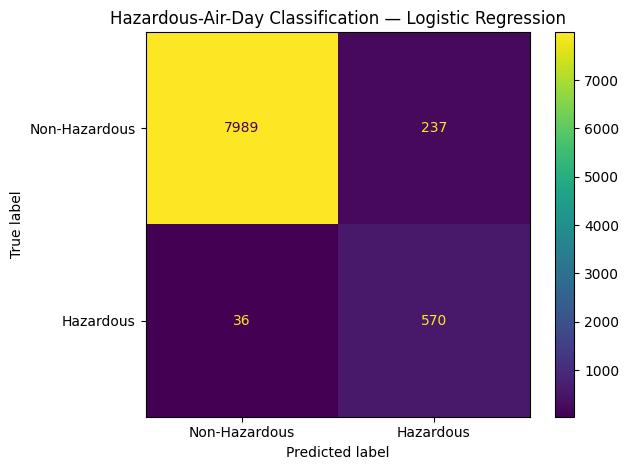

Confusion matrix saved successfully.


In [24]:
# ============================================================
# W4 CELL 22 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test_cls,
    y_pred_cls
)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Non-Hazardous",
        "Hazardous"
    ]
)

disp.plot()

plt.title(
    "Hazardous-Air-Day Classification — Logistic Regression"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w4_logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved successfully.")

In [25]:
# ============================================================
# W4 CELL 23 — SAVE CLASSIFICATION RESULTS
# ============================================================

classification_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print("=" * 70)
print("HAZARDOUS-AIR-DAY RESULTS")
print("=" * 70)

display(classification_results)

classification_results.to_csv(
    "../graphs/w4_logistic_results.csv",
    index=False
)

print("Classification results saved successfully.")

HAZARDOUS-AIR-DAY RESULTS


,Metric,Score
0,Accuracy,0.969090
1,Precision,0.706320
2,Recall,0.940594
3,F1 Score,0.806794
4,ROC-AUC,0.991235


Classification results saved successfully.


In [26]:
# ============================================================
# W4 CELL 24 — FEATURE ENGINEERING
# ============================================================

# Work on a copy of the cleaned dataset
df_fe = df.copy()

# Sort chronologically within each city
df_fe = df_fe.sort_values(
    ["City", "Date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 1. Current AQI
# ------------------------------------------------------------

df_fe["AQI_Current"] = df_fe["AQI"]

# ------------------------------------------------------------
# 2. Previous-day AQI
# ------------------------------------------------------------

df_fe["AQI_Lag1"] = (
    df_fe.groupby("City")["AQI"]
    .shift(1)
)

# ------------------------------------------------------------
# 3. Three-day historical AQI average
#    Includes current day and previous 2 days
# ------------------------------------------------------------

df_fe["AQI_3Day_Mean"] = (
    df_fe.groupby("City")["AQI"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

# ------------------------------------------------------------
# 4. Day of week
# Monday = 0, Sunday = 6
# ------------------------------------------------------------

df_fe["DayOfWeek"] = (
    df_fe["Date"].dt.dayofweek
)

# ------------------------------------------------------------
# 5. Month
# ------------------------------------------------------------

df_fe["Month"] = (
    df_fe["Date"].dt.month
)

print("=" * 70)
print("W4 FEATURE ENGINEERING")
print("=" * 70)

new_features = [
    "AQI_Current",
    "AQI_Lag1",
    "AQI_3Day_Mean",
    "DayOfWeek",
    "Month"
]

print("New engineered features:")

for feature in new_features:
    print("-", feature)

display(
    df_fe[
        [
            "City",
            "Date",
            "AQI",
            "Tomorrow_AQI",
            "AQI_Current",
            "AQI_Lag1",
            "AQI_3Day_Mean",
            "DayOfWeek",
            "Month"
        ]
    ].head(10)
)

W4 FEATURE ENGINEERING
New engineered features:
- AQI_Current
- AQI_Lag1
- AQI_3Day_Mean
- DayOfWeek
- Month


,City,Date,AQI,Tomorrow_AQI,AQI_Current,AQI_Lag1,AQI_3Day_Mean,DayOfWeek,Month
0,Ahmedabad,2015-01-28,NaN,209.0,NaN,NaN,NaN,2,1
1,Ahmedabad,2015-01-29,209.0,328.0,209.0,NaN,209.000000,3,1
2,Ahmedabad,2015-01-30,328.0,514.0,328.0,209.0,268.500000,4,1
3,Ahmedabad,2015-01-31,514.0,782.0,514.0,328.0,350.333333,5,1
4,Ahmedabad,2015-02-01,782.0,914.0,782.0,514.0,541.333333,6,2
5,Ahmedabad,2015-02-02,914.0,660.0,914.0,782.0,736.666667,0,2
6,Ahmedabad,2015-02-03,660.0,294.0,660.0,914.0,785.333333,1,2
7,Ahmedabad,2015-02-04,294.0,149.0,294.0,660.0,622.666667,2,2
8,Ahmedabad,2015-02-05,149.0,190.0,149.0,294.0,367.666667,3,2
9,Ahmedabad,2015-02-06,190.0,247.0,190.0,149.0,211.000000,4,2


In [27]:
# ============================================================
# W4 CELL 25 — CHECK ENGINEERED FEATURES
# ============================================================

print("=" * 70)
print("ENGINEERED FEATURE MISSING VALUES")
print("=" * 70)

print(
    df_fe[
        new_features
    ].isna().sum()
)

print("\nRows before removing missing lag values:")
print(len(df_fe))

ENGINEERED FEATURE MISSING VALUES
AQI_Current      506
AQI_Lag1         532
AQI_3Day_Mean     30
DayOfWeek          0
Month              0
dtype: int64

Rows before removing missing lag values:
24849


In [28]:
# ============================================================
# W4 CELL 26 — TRAIN / TEST SPLIT WITH ENGINEERED FEATURES
# ============================================================

df_fe = df_fe.dropna(
    subset=["AQI_Lag1"]
).copy()

df_fe = df_fe.sort_values(
    ["Date", "City"]
).reset_index(drop=True)

unique_dates_fe = sorted(
    df_fe["Date"].unique()
)

split_index_fe = int(
    len(unique_dates_fe) * 0.80
)

split_date_fe = unique_dates_fe[
    split_index_fe
]

train_fe = df_fe[
    df_fe["Date"] < split_date_fe
].copy()

test_fe = df_fe[
    df_fe["Date"] >= split_date_fe
].copy()

print("=" * 70)
print("W4 FEATURE-ENGINEERED SPLIT")
print("=" * 70)

print("Split date:", split_date_fe)

print("Train rows:", len(train_fe))
print("Test rows :", len(test_fe))

print(
    "\nCommon dates:",
    len(
        set(train_fe["Date"])
        .intersection(set(test_fe["Date"]))
    )
)

W4 FEATURE-ENGINEERED SPLIT
Split date: 2019-05-26 00:00:00
Train rows: 15636
Test rows : 8681

Common dates: 0


In [29]:
# ============================================================
# W4 CELL 27 — FINAL ENGINEERED FEATURE SET
# ============================================================

pollutant_features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene"
]

engineered_features = [
    "AQI_Current",
    "AQI_Lag1",
    "AQI_3Day_Mean",
    "DayOfWeek",
    "Month"
]

features_fe = (
    pollutant_features +
    engineered_features
)

print("=" * 70)
print("FINAL FEATURE SET")
print("=" * 70)

print("Pollutant features :", len(pollutant_features))
print("Engineered features:", len(engineered_features))
print("Total features     :", len(features_fe))

print("\nFeatures:")

for feature in features_fe:
    print("-", feature)

FINAL FEATURE SET
Pollutant features : 11
Engineered features: 5
Total features     : 16

Features:
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- AQI_Current
- AQI_Lag1
- AQI_3Day_Mean
- DayOfWeek
- Month


In [30]:
# ============================================================
# W4 CELL 28 — IMPUTE ENGINEERED DATA
# ============================================================

train_fe_imp = train_fe.copy()
test_fe_imp = test_fe.copy()

for col in features_fe:

    # City median from training data only
    city_medians = (
        train_fe_imp
        .groupby("City")[col]
        .median()
    )

    # Overall training median
    overall_median = (
        train_fe_imp[col].median()
    )

    # Training
    train_fe_imp[col] = (
        train_fe_imp[col]
        .fillna(
            train_fe_imp["City"].map(
                city_medians
            )
        )
        .fillna(overall_median)
    )

    # Test
    test_fe_imp[col] = (
        test_fe_imp[col]
        .fillna(
            test_fe_imp["City"].map(
                city_medians
            )
        )
        .fillna(overall_median)
    )

print("=" * 70)
print("ENGINEERED DATA IMPUTATION")
print("=" * 70)

print(
    "Training missing values:",
    train_fe_imp[
        features_fe
    ].isna().sum().sum()
)

print(
    "Testing missing values:",
    test_fe_imp[
        features_fe
    ].isna().sum().sum()
)

ENGINEERED DATA IMPUTATION
Training missing values: 0
Testing missing values: 0


In [31]:
# ============================================================
# W4 CELL 29 — SCALE ENGINEERED FEATURES
# ============================================================

X_train_fe = train_fe_imp[
    features_fe
]

X_test_fe = test_fe_imp[
    features_fe
]

y_train_fe = train_fe_imp[
    "Tomorrow_AQI"
]

y_test_fe = test_fe_imp[
    "Tomorrow_AQI"
]

scaler_fe = StandardScaler()

X_train_fe_scaled = (
    scaler_fe.fit_transform(
        X_train_fe
    )
)

X_test_fe_scaled = (
    scaler_fe.transform(
        X_test_fe
    )
)

print("=" * 70)
print("ENGINEERED ML DATASET")
print("=" * 70)

print(
    "X_train:",
    X_train_fe_scaled.shape
)

print(
    "X_test :",
    X_test_fe_scaled.shape
)

print(
    "y_train:",
    y_train_fe.shape
)

print(
    "y_test :",
    y_test_fe.shape
)

ENGINEERED ML DATASET
X_train: (15636, 16)
X_test : (8681, 16)
y_train: (15636,)
y_test : (8681,)


In [32]:
# ============================================================
# W4 CELL 30 — FEATURE-ENGINEERED RIDGE
# ============================================================

ridge_fe = Ridge(
    alpha=1.0
)

ridge_fe.fit(
    X_train_fe_scaled,
    y_train_fe
)

y_pred_ridge_fe = ridge_fe.predict(
    X_test_fe_scaled
)

ridge_fe_mae = mean_absolute_error(
    y_test_fe,
    y_pred_ridge_fe
)

ridge_fe_rmse = np.sqrt(
    mean_squared_error(
        y_test_fe,
        y_pred_ridge_fe
    )
)

ridge_fe_r2 = r2_score(
    y_test_fe,
    y_pred_ridge_fe
)

print("=" * 70)
print("FEATURE-ENGINEERED RIDGE")
print("=" * 70)

print(f"MAE  : {ridge_fe_mae:.4f}")
print(f"RMSE : {ridge_fe_rmse:.4f}")
print(f"R²   : {ridge_fe_r2:.4f}")

FEATURE-ENGINEERED RIDGE
MAE  : 22.1350
RMSE : 40.7277
R²   : 0.8452


In [33]:
# ============================================================
# W4 CELL 31 — FEATURE-ENGINEERED LASSO
# ============================================================

lasso_fe = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_fe.fit(
    X_train_fe_scaled,
    y_train_fe
)

y_pred_lasso_fe = lasso_fe.predict(
    X_test_fe_scaled
)

lasso_fe_mae = mean_absolute_error(
    y_test_fe,
    y_pred_lasso_fe
)

lasso_fe_rmse = np.sqrt(
    mean_squared_error(
        y_test_fe,
        y_pred_lasso_fe
    )
)

lasso_fe_r2 = r2_score(
    y_test_fe,
    y_pred_lasso_fe
)

print("=" * 70)
print("FEATURE-ENGINEERED LASSO")
print("=" * 70)

print(f"MAE  : {lasso_fe_mae:.4f}")
print(f"RMSE : {lasso_fe_rmse:.4f}")
print(f"R²   : {lasso_fe_r2:.4f}")

FEATURE-ENGINEERED LASSO
MAE  : 22.1285
RMSE : 40.7153
R²   : 0.8452


In [34]:
# ============================================================
# W4 CELL 32 — FEATURE ENGINEERING COMPARISON
# ============================================================

feature_comparison = pd.DataFrame({
    "Model": [
        "Original Lasso (11 features)",
        "Engineered Ridge (16 features)",
        "Engineered Lasso (16 features)"
    ],
    "MAE": [
        lasso_mae,
        ridge_fe_mae,
        lasso_fe_mae
    ],
    "RMSE": [
        lasso_rmse,
        ridge_fe_rmse,
        lasso_fe_rmse
    ],
    "R2": [
        lasso_r2,
        ridge_fe_r2,
        lasso_fe_r2
    ]
})

print("=" * 70)
print("FEATURE ENGINEERING MODEL COMPARISON")
print("=" * 70)

display(feature_comparison)

FEATURE ENGINEERING MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Original Lasso (11 features),25.688423,42.459937,0.833186
1,Engineered Ridge (16 features),22.134959,40.727729,0.845156
2,Engineered Lasso (16 features),22.128465,40.715327,0.845250


In [35]:
# ============================================================
# W4 CELL 33 — SAVE FEATURE ENGINEERING RESULTS
# ============================================================

feature_comparison.to_csv(
    "../graphs/w4_feature_engineering_comparison.csv",
    index=False
)

print("Feature engineering comparison saved successfully.")

Feature engineering comparison saved successfully.


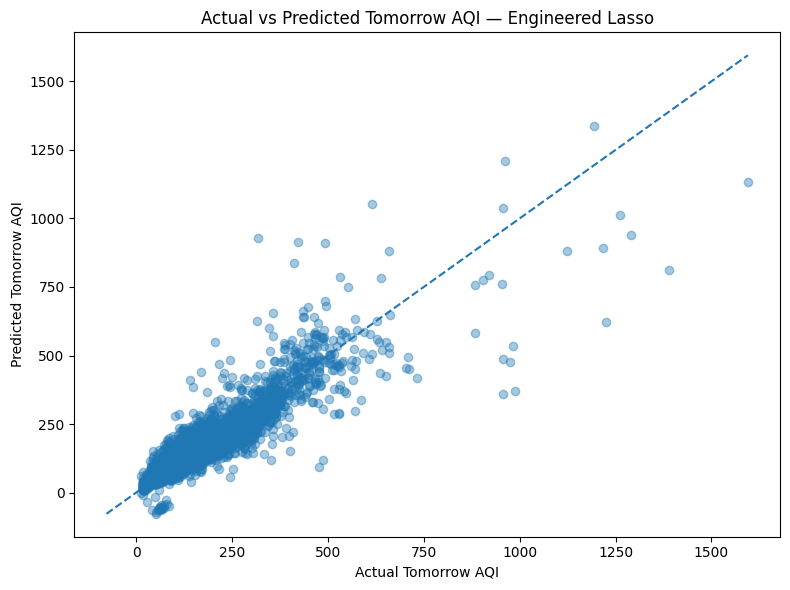

Best-model graph saved successfully.


In [36]:
# ============================================================
# W4 CELL 34 — BEST MODEL ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_fe,
    y_pred_lasso_fe,
    alpha=0.4
)

min_value = min(
    y_test_fe.min(),
    y_pred_lasso_fe.min()
)

max_value = max(
    y_test_fe.max(),
    y_pred_lasso_fe.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Tomorrow AQI")
plt.ylabel("Predicted Tomorrow AQI")

plt.title(
    "Actual vs Predicted Tomorrow AQI — Engineered Lasso"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w4_engineered_lasso_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Best-model graph saved successfully.")

In [37]:
# ============================================================
# W4 CELL 35 — ENGINEERED LASSO RESIDUAL ANALYSIS
# ============================================================

lasso_fe_residuals = (
    y_test_fe.values - y_pred_lasso_fe
)

print("=" * 70)
print("ENGINEERED LASSO RESIDUAL ANALYSIS")
print("=" * 70)

print(
    f"Mean residual: {np.mean(lasso_fe_residuals):.4f}"
)

print(
    f"Std residual : {np.std(lasso_fe_residuals):.4f}"
)

print(
    f"Min residual : {np.min(lasso_fe_residuals):.4f}"
)

print(
    f"Max residual : {np.max(lasso_fe_residuals):.4f}"
)

ENGINEERED LASSO RESIDUAL ANALYSIS
Mean residual: -1.7506
Std residual : 40.6777
Min residual : -609.6782
Max residual : 615.5456


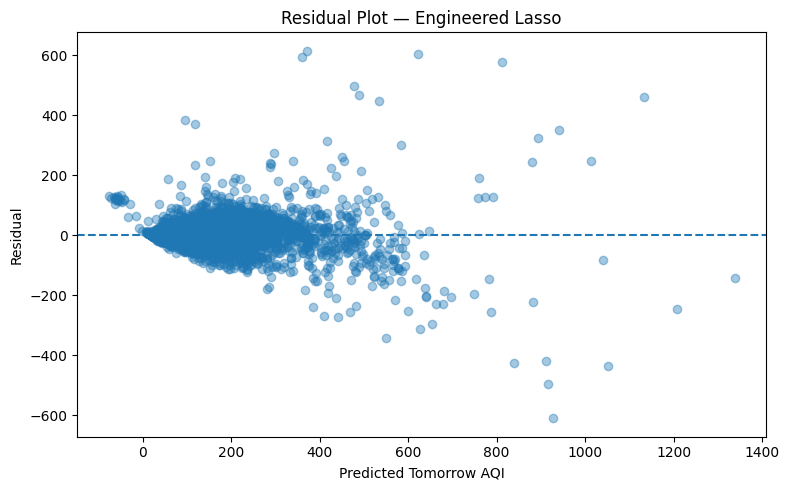

Residual graph saved successfully.


In [38]:
# ============================================================
# W4 CELL 36 — ENGINEERED LASSO RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_lasso_fe,
    lasso_fe_residuals,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Tomorrow AQI")
plt.ylabel("Residual")

plt.title(
    "Residual Plot — Engineered Lasso"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w4_engineered_lasso_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Residual graph saved successfully.")

In [39]:
# ============================================================
# W4 CELL 37 — LASSO COEFFICIENT ANALYSIS
# ============================================================

coefficient_df = pd.DataFrame({
    "Feature": features_fe,
    "Coefficient": lasso_fe.coef_
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("ENGINEERED LASSO COEFFICIENTS")
print("=" * 70)

display(coefficient_df)

ENGINEERED LASSO COEFFICIENTS


,Feature,Coefficient,Absolute_Coefficient
0,CO,54.114640,54.114640
1,AQI_3Day_Mean,50.191270,50.191270
2,PM2.5,43.075686,43.075686
3,AQI_Current,26.275007,26.275007
4,AQI_Lag1,-19.320732,19.320732
5,PM10,14.597702,14.597702
6,SO2,8.320678,8.320678
7,NO2,5.617038,5.617038
8,O3,4.108482,4.108482
9,NOx,3.125229,3.125229


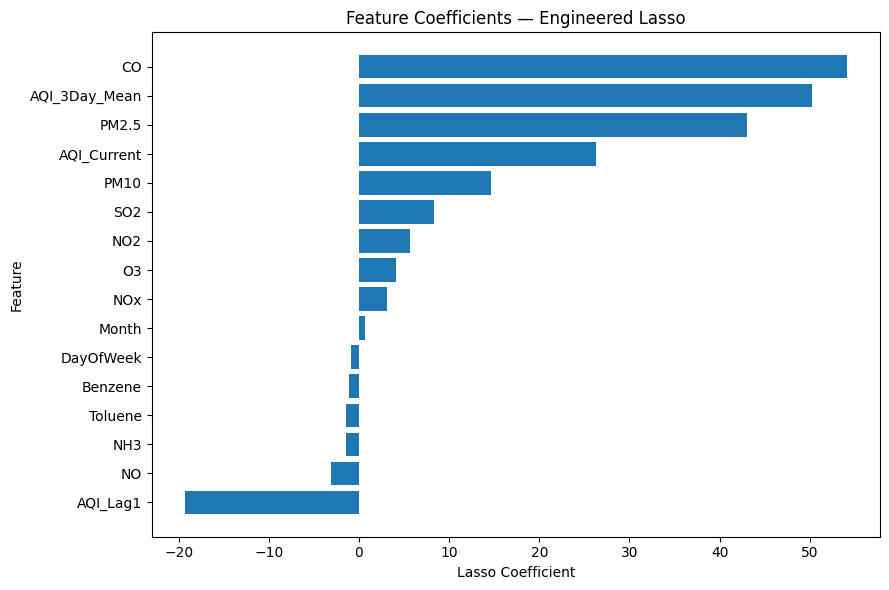

Coefficient graph saved successfully.


In [40]:
# ============================================================
# W4 CELL 38 — LASSO COEFFICIENT PLOT
# ============================================================

plot_df = coefficient_df.sort_values(
    "Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)

plt.xlabel("Lasso Coefficient")
plt.ylabel("Feature")

plt.title(
    "Feature Coefficients — Engineered Lasso"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w4_lasso_feature_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Coefficient graph saved successfully.")

In [41]:
# ============================================================
# W4 CELL 39 — SAVE LASSO COEFFICIENTS
# ============================================================

coefficient_df.to_csv(
    "../graphs/w4_lasso_coefficients.csv",
    index=False
)

print("=" * 70)
print("LASSO COEFFICIENT ANALYSIS SAVED")
print("=" * 70)

print("Saved successfully:")
print("../graphs/w4_lasso_coefficients.csv")

LASSO COEFFICIENT ANALYSIS SAVED
Saved successfully:
../graphs/w4_lasso_coefficients.csv


In [42]:
# ============================================================
# W4 CELL 40 — FINAL REGRESSION SUMMARY
# ============================================================

final_regression_summary = pd.DataFrame({
    "Model": [
        "OLS",
        "Ridge",
        "Lasso",
        "Engineered Ridge",
        "Engineered Lasso"
    ],
    "Features": [
        11,
        11,
        11,
        16,
        16
    ],
    "MAE": [
        ols_mae_w4,
        ridge_mae,
        lasso_mae,
        ridge_fe_mae,
        lasso_fe_mae
    ],
    "RMSE": [
        ols_rmse_w4,
        ridge_rmse,
        lasso_rmse,
        ridge_fe_rmse,
        lasso_fe_rmse
    ],
    "R2": [
        ols_r2_w4,
        ridge_r2,
        lasso_r2,
        ridge_fe_r2,
        lasso_fe_r2
    ]
})

print("=" * 70)
print("AEROPURE — W4 FINAL REGRESSION SUMMARY")
print("=" * 70)

display(final_regression_summary)

final_regression_summary.to_csv(
    "../graphs/w4_final_regression_summary.csv",
    index=False
)

print("Final regression summary saved successfully.")

AEROPURE — W4 FINAL REGRESSION SUMMARY


,Model,Features,MAE,RMSE,R2
0,OLS,11,25.694745,42.475218,0.833065
1,Ridge,11,25.695081,42.474451,0.833072
2,Lasso,11,25.688423,42.459937,0.833186
3,Engineered Ridge,16,22.134959,40.727729,0.845156
4,Engineered Lasso,16,22.128465,40.715327,0.845250


Final regression summary saved successfully.


In [43]:
# ============================================================
# W5 CELL 41 — TIME-BASED CROSS-VALIDATION SETUP
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

print("=" * 70)
print("W5 CROSS-VALIDATION SETUP")
print("=" * 70)

# Use the already prepared feature-engineered training data
X_cv = X_train_fe_scaled
y_cv = y_train_fe

# 5 sequential folds
tscv = TimeSeriesSplit(
    n_splits=5
)

print("Number of CV folds:", tscv.n_splits)

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_cv),
    start=1
):
    print(
        f"Fold {fold}: "
        f"Train = {len(train_idx)}, "
        f"Validation = {len(val_idx)}"
    )

W5 CROSS-VALIDATION SETUP
Number of CV folds: 5
Fold 1: Train = 2606, Validation = 2606
Fold 2: Train = 5212, Validation = 2606
Fold 3: Train = 7818, Validation = 2606
Fold 4: Train = 10424, Validation = 2606
Fold 5: Train = 13030, Validation = 2606


In [44]:
# ============================================================
# W5 CELL 42 — RIDGE CROSS-VALIDATION
# ============================================================

ridge_alphas = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

ridge_cv_results = []

for alpha in ridge_alphas:

    fold_mae = []

    for train_idx, val_idx in tscv.split(X_cv):

        X_tr = X_cv[train_idx]
        X_val = X_cv[val_idx]

        y_tr = y_cv.iloc[train_idx]
        y_val = y_cv.iloc[val_idx]

        model = Ridge(
            alpha=alpha
        )

        model.fit(
            X_tr,
            y_tr
        )

        pred = model.predict(
            X_val
        )

        mae = mean_absolute_error(
            y_val,
            pred
        )

        fold_mae.append(mae)

    ridge_cv_results.append({
        "Alpha": alpha,
        "Mean_MAE": np.mean(fold_mae),
        "Std_MAE": np.std(
            fold_mae,
            ddof=1
        ),
        "SE_MAE": (
            np.std(
                fold_mae,
                ddof=1
            )
            / np.sqrt(len(fold_mae))
        )
    })

ridge_cv_results = pd.DataFrame(
    ridge_cv_results
)

print("=" * 70)
print("RIDGE CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    ridge_cv_results
)

RIDGE CROSS-VALIDATION RESULTS


,Alpha,Mean_MAE,Std_MAE,SE_MAE
0,0.001,35.561301,2.794256,1.249629
1,0.010,35.561323,2.794246,1.249625
2,0.100,35.561539,2.794143,1.249579
3,1.000,35.563699,2.793121,1.249122
4,10.000,35.585295,2.783611,1.244869
5,100.000,35.805027,2.760939,1.234729


In [45]:
# ============================================================
# W5 CELL 43 — BEST RIDGE ALPHA
# ============================================================

best_ridge_idx = (
    ridge_cv_results["Mean_MAE"]
    .idxmin()
)

best_ridge_alpha = (
    ridge_cv_results
    .loc[best_ridge_idx, "Alpha"]
)

best_ridge_mae = (
    ridge_cv_results
    .loc[best_ridge_idx, "Mean_MAE"]
)

best_ridge_se = (
    ridge_cv_results
    .loc[best_ridge_idx, "SE_MAE"]
)

print("=" * 70)
print("BEST RIDGE MODEL")
print("=" * 70)

print(
    "Best alpha:",
    best_ridge_alpha
)

print(
    f"Best CV MAE: {best_ridge_mae:.4f}"
)

print(
    f"Standard error: {best_ridge_se:.4f}"
)

BEST RIDGE MODEL
Best alpha: 0.001
Best CV MAE: 35.5613
Standard error: 1.2496


In [46]:
# ============================================================
# W5 CELL 44 — RIDGE ONE-STANDARD-ERROR RULE
# ============================================================

ridge_threshold = (
    best_ridge_mae +
    best_ridge_se
)

ridge_candidates_1se = (
    ridge_cv_results[
        ridge_cv_results["Mean_MAE"]
        <= ridge_threshold
    ]
)

ridge_alpha_1se = (
    ridge_candidates_1se["Alpha"]
    .max()
)

print("=" * 70)
print("RIDGE ONE-STANDARD-ERROR RULE")
print("=" * 70)

print(
    f"Best CV MAE: {best_ridge_mae:.4f}"
)

print(
    f"Best CV SE : {best_ridge_se:.4f}"
)

print(
    f"1-SE threshold: {ridge_threshold:.4f}"
)

print(
    "Selected alpha using 1-SE rule:",
    ridge_alpha_1se
)

print("\nCandidate models within 1-SE:")

display(
    ridge_candidates_1se
)

RIDGE ONE-STANDARD-ERROR RULE
Best CV MAE: 35.5613
Best CV SE : 1.2496
1-SE threshold: 36.8109
Selected alpha using 1-SE rule: 100.0

Candidate models within 1-SE:


,Alpha,Mean_MAE,Std_MAE,SE_MAE
0,0.001,35.561301,2.794256,1.249629
1,0.010,35.561323,2.794246,1.249625
2,0.100,35.561539,2.794143,1.249579
3,1.000,35.563699,2.793121,1.249122
4,10.000,35.585295,2.783611,1.244869
5,100.000,35.805027,2.760939,1.234729


In [47]:
# ============================================================
# W5 CELL 45 — LASSO CROSS-VALIDATION
# ============================================================

lasso_alphas = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1.0,
    10.0
]

lasso_cv_results = []

for alpha in lasso_alphas:

    fold_mae = []

    for train_idx, val_idx in tscv.split(X_cv):

        X_tr = X_cv[train_idx]
        X_val = X_cv[val_idx]

        y_tr = y_cv.iloc[train_idx]
        y_val = y_cv.iloc[val_idx]

        model = Lasso(
            alpha=alpha,
            max_iter=20000
        )

        model.fit(
            X_tr,
            y_tr
        )

        pred = model.predict(
            X_val
        )

        mae = mean_absolute_error(
            y_val,
            pred
        )

        fold_mae.append(mae)

    lasso_cv_results.append({
        "Alpha": alpha,
        "Mean_MAE": np.mean(fold_mae),
        "Std_MAE": np.std(
            fold_mae,
            ddof=1
        ),
        "SE_MAE": (
            np.std(
                fold_mae,
                ddof=1
            )
            / np.sqrt(len(fold_mae))
        )
    })

lasso_cv_results = pd.DataFrame(
    lasso_cv_results
)

print("=" * 70)
print("LASSO CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    lasso_cv_results
)

LASSO CROSS-VALIDATION RESULTS


,Alpha,Mean_MAE,Std_MAE,SE_MAE
0,0.0001,35.561339,2.794224,1.249615
1,0.0010,35.561701,2.793927,1.249482
2,0.0100,35.564800,2.789725,1.247603
3,0.1000,35.600328,2.745572,1.227857
4,1.0000,35.768762,2.597678,1.161717
5,10.0000,39.789489,2.730111,1.220943


In [48]:
# ============================================================
# W5 CELL 46 — LASSO ONE-STANDARD-ERROR RULE
# ============================================================

best_lasso_idx = (
    lasso_cv_results["Mean_MAE"]
    .idxmin()
)

best_lasso_alpha = (
    lasso_cv_results
    .loc[best_lasso_idx, "Alpha"]
)

best_lasso_mae = (
    lasso_cv_results
    .loc[best_lasso_idx, "Mean_MAE"]
)

best_lasso_se = (
    lasso_cv_results
    .loc[best_lasso_idx, "SE_MAE"]
)

lasso_threshold = (
    best_lasso_mae +
    best_lasso_se
)

lasso_candidates_1se = (
    lasso_cv_results[
        lasso_cv_results["Mean_MAE"]
        <= lasso_threshold
    ]
)

lasso_alpha_1se = (
    lasso_candidates_1se["Alpha"]
    .max()
)

print("=" * 70)
print("LASSO ONE-STANDARD-ERROR RULE")
print("=" * 70)

print(
    "Best alpha:",
    best_lasso_alpha
)

print(
    f"Best CV MAE: {best_lasso_mae:.4f}"
)

print(
    f"Standard error: {best_lasso_se:.4f}"
)

print(
    f"1-SE threshold: {lasso_threshold:.4f}"
)

print(
    "Selected alpha using 1-SE rule:",
    lasso_alpha_1se
)

print("\nCandidate models within 1-SE:")

display(
    lasso_candidates_1se
)

LASSO ONE-STANDARD-ERROR RULE
Best alpha: 0.0001
Best CV MAE: 35.5613
Standard error: 1.2496
1-SE threshold: 36.8110
Selected alpha using 1-SE rule: 1.0

Candidate models within 1-SE:


,Alpha,Mean_MAE,Std_MAE,SE_MAE
0,0.0001,35.561339,2.794224,1.249615
1,0.0010,35.561701,2.793927,1.249482
2,0.0100,35.564800,2.789725,1.247603
3,0.1000,35.600328,2.745572,1.227857
4,1.0000,35.768762,2.597678,1.161717


In [49]:
# ============================================================
# W5 CELL 47 — FINAL TUNED RIDGE
# ============================================================

final_ridge = Ridge(
    alpha=ridge_alpha_1se
)

final_ridge.fit(
    X_train_fe_scaled,
    y_train_fe
)

y_pred_final_ridge = final_ridge.predict(
    X_test_fe_scaled
)

final_ridge_mae = mean_absolute_error(
    y_test_fe,
    y_pred_final_ridge
)

final_ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test_fe,
        y_pred_final_ridge
    )
)

final_ridge_r2 = r2_score(
    y_test_fe,
    y_pred_final_ridge
)

print("=" * 70)
print("FINAL TUNED RIDGE — 1-SE MODEL")
print("=" * 70)

print("Selected alpha:", ridge_alpha_1se)
print(f"MAE  : {final_ridge_mae:.4f}")
print(f"RMSE : {final_ridge_rmse:.4f}")
print(f"R²   : {final_ridge_r2:.4f}")

FINAL TUNED RIDGE — 1-SE MODEL
Selected alpha: 100.0
MAE  : 22.1342
RMSE : 40.7133
R²   : 0.8453


In [50]:
# ============================================================
# W5 CELL 48 — FINAL TUNED LASSO
# ============================================================

final_lasso = Lasso(
    alpha=lasso_alpha_1se,
    max_iter=20000
)

final_lasso.fit(
    X_train_fe_scaled,
    y_train_fe
)

y_pred_final_lasso = final_lasso.predict(
    X_test_fe_scaled
)

final_lasso_mae = mean_absolute_error(
    y_test_fe,
    y_pred_final_lasso
)

final_lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test_fe,
        y_pred_final_lasso
    )
)

final_lasso_r2 = r2_score(
    y_test_fe,
    y_pred_final_lasso
)

print("=" * 70)
print("FINAL TUNED LASSO — 1-SE MODEL")
print("=" * 70)

print("Selected alpha:", lasso_alpha_1se)
print(f"MAE  : {final_lasso_mae:.4f}")
print(f"RMSE : {final_lasso_rmse:.4f}")
print(f"R²   : {final_lasso_r2:.4f}")

FINAL TUNED LASSO — 1-SE MODEL
Selected alpha: 1.0
MAE  : 21.9038
RMSE : 40.3824
R²   : 0.8478


In [51]:
# ============================================================
# W5 CELL 49 — FINAL TUNED MODEL COMPARISON
# ============================================================

w5_regression_results = pd.DataFrame({
    "Model": [
        "Ridge — 1-SE",
        "Lasso — 1-SE"
    ],
    "Alpha": [
        ridge_alpha_1se,
        lasso_alpha_1se
    ],
    "MAE": [
        final_ridge_mae,
        final_lasso_mae
    ],
    "RMSE": [
        final_ridge_rmse,
        final_lasso_rmse
    ],
    "R2": [
        final_ridge_r2,
        final_lasso_r2
    ]
})

print("=" * 70)
print("W5 FINAL TUNED REGRESSION RESULTS")
print("=" * 70)

display(w5_regression_results)

W5 FINAL TUNED REGRESSION RESULTS


,Model,Alpha,MAE,RMSE,R2
0,Ridge — 1-SE,100.0,22.134196,40.713274,0.845266
1,Lasso — 1-SE,1.0,21.903789,40.382361,0.847771


In [52]:
# ============================================================
# W5 CELL 50 — SAVE TUNED RESULTS
# ============================================================

w5_regression_results.to_csv(
    "../graphs/w5_tuned_regression_results.csv",
    index=False
)

ridge_cv_results.to_csv(
    "../graphs/w5_ridge_cv_results.csv",
    index=False
)

lasso_cv_results.to_csv(
    "../graphs/w5_lasso_cv_results.csv",
    index=False
)

print("W5 regression results saved successfully.")

W5 regression results saved successfully.


In [54]:
# ============================================================
# W5 CELL 50A — HAZARDOUS TARGET FOR FEATURE-ENGINEERED DATA
# ============================================================

HAZARDOUS_THRESHOLD = 301

train_fe_imp["Hazardous_Tomorrow"] = (
    train_fe_imp["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

test_fe_imp["Hazardous_Tomorrow"] = (
    test_fe_imp["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

print("=" * 70)
print("W5 HAZARDOUS TARGET CHECK")
print("=" * 70)

print("Threshold:", HAZARDOUS_THRESHOLD)

print("\nTRAIN:")
print(
    train_fe_imp["Hazardous_Tomorrow"]
    .value_counts()
    .sort_index()
)

print("\nTEST:")
print(
    test_fe_imp["Hazardous_Tomorrow"]
    .value_counts()
    .sort_index()
)

W5 HAZARDOUS TARGET CHECK
Threshold: 301

TRAIN:
Hazardous_Tomorrow
0    12642
1     2994
Name: count, dtype: int64

TEST:
Hazardous_Tomorrow
0    8082
1     599
Name: count, dtype: int64


In [56]:
# ============================================================
# W5 CELL 51 — LOGISTIC REGRESSION CROSS-VALIDATION
# ============================================================

logistic_C_values = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

logistic_cv_results = []

# Use the same time-based CV folds
for C in logistic_C_values:

    fold_f1 = []
    fold_recall = []

    for train_idx, val_idx in tscv.split(X_cv):

        # -----------------------------
        # Split features
        # -----------------------------
        X_tr = X_cv[train_idx]
        X_val = X_cv[val_idx]

        # -----------------------------
        # Split classification target
        # -----------------------------
        y_tr = (
            train_fe_imp["Hazardous_Tomorrow"]
            .iloc[train_idx]
        )

        y_val = (
            train_fe_imp["Hazardous_Tomorrow"]
            .iloc[val_idx]
        )

        # -----------------------------
        # Logistic Regression
        # -----------------------------
        model = LogisticRegression(
            C=C,
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )

        # Train
        model.fit(
            X_tr,
            y_tr
        )

        # Predict
        pred = model.predict(
            X_val
        )

        # -----------------------------
        # Evaluation
        # -----------------------------
        fold_f1.append(
            f1_score(
                y_val,
                pred,
                zero_division=0
            )
        )

        fold_recall.append(
            recall_score(
                y_val,
                pred,
                zero_division=0
            )
        )

    # -----------------------------
    # Store CV results
    # -----------------------------
    logistic_cv_results.append({
        "C": C,
        "Mean_F1": np.mean(fold_f1),
        "Std_F1": np.std(
            fold_f1,
            ddof=1
        ),
        "SE_F1": (
            np.std(
                fold_f1,
                ddof=1
            )
            / np.sqrt(len(fold_f1))
        ),
        "Mean_Recall": np.mean(
            fold_recall
        )
    })


# Convert to DataFrame
logistic_cv_results = pd.DataFrame(
    logistic_cv_results
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 70)
print("LOGISTIC REGRESSION CROSS-VALIDATION")
print("=" * 70)

display(
    logistic_cv_results
)

LOGISTIC REGRESSION CROSS-VALIDATION


,C,Mean_F1,Std_F1,SE_F1,Mean_Recall
0,0.001,0.812633,0.050569,0.022615,0.930664
1,0.010,0.829189,0.043844,0.019607,0.936583
2,0.100,0.832660,0.042945,0.019206,0.929061
3,1.000,0.834495,0.039160,0.017513,0.928421
4,10.000,0.835008,0.039575,0.017699,0.929125
5,100.000,0.834851,0.039435,0.017636,0.929125


In [57]:
# ============================================================
# W5 CELL 52 — LOGISTIC REGRESSION 1-SE RULE
# ============================================================

# Find the model with highest mean F1
best_logistic_idx = (
    logistic_cv_results["Mean_F1"]
    .idxmax()
)

best_logistic_C = (
    logistic_cv_results
    .loc[best_logistic_idx, "C"]
)

best_logistic_f1 = (
    logistic_cv_results
    .loc[best_logistic_idx, "Mean_F1"]
)

best_logistic_se = (
    logistic_cv_results
    .loc[best_logistic_idx, "SE_F1"]
)

# For maximizing F1:
# acceptable models must be within 1 SE below
f1_threshold = (
    best_logistic_f1 -
    best_logistic_se
)

logistic_candidates_1se = (
    logistic_cv_results[
        logistic_cv_results["Mean_F1"]
        >= f1_threshold
    ]
)

# Smaller C = stronger regularization
# Choose the smallest acceptable C
logistic_C_1se = (
    logistic_candidates_1se["C"]
    .min()
)

print("=" * 70)
print("LOGISTIC REGRESSION — ONE STANDARD ERROR RULE")
print("=" * 70)

print(
    f"Best C: {best_logistic_C}"
)

print(
    f"Best CV F1: {best_logistic_f1:.4f}"
)

print(
    f"SE: {best_logistic_se:.4f}"
)

print(
    f"1-SE threshold: {f1_threshold:.4f}"
)

print(
    f"Selected C using 1-SE rule: {logistic_C_1se}"
)

print("\nModels within 1-SE:")

display(
    logistic_candidates_1se
)

LOGISTIC REGRESSION — ONE STANDARD ERROR RULE
Best C: 10.0
Best CV F1: 0.8350
SE: 0.0177
1-SE threshold: 0.8173
Selected C using 1-SE rule: 0.01

Models within 1-SE:


,C,Mean_F1,Std_F1,SE_F1,Mean_Recall
1,0.01,0.829189,0.043844,0.019607,0.936583
2,0.10,0.832660,0.042945,0.019206,0.929061
3,1.00,0.834495,0.039160,0.017513,0.928421
4,10.00,0.835008,0.039575,0.017699,0.929125
5,100.00,0.834851,0.039435,0.017636,0.929125


In [58]:
# ============================================================
# W5 CELL 53 — FINAL TUNED LOGISTIC REGRESSION
# ============================================================

final_logistic = LogisticRegression(
    C=logistic_C_1se,
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

final_logistic.fit(
    X_train_fe_scaled,
    train_fe_imp["Hazardous_Tomorrow"]
)

# Final test predictions
y_pred_final_cls = final_logistic.predict(
    X_test_fe_scaled
)

y_prob_final_cls = (
    final_logistic
    .predict_proba(X_test_fe_scaled)[:, 1]
)

print("=" * 70)
print("FINAL TUNED LOGISTIC REGRESSION")
print("=" * 70)

print(
    "Selected C:",
    logistic_C_1se
)

print(
    "Test predictions:",
    len(y_pred_final_cls)
)

FINAL TUNED LOGISTIC REGRESSION
Selected C: 0.01
Test predictions: 8681


In [59]:
# ============================================================
# W5 CELL 54 — FINAL LOGISTIC EVALUATION
# ============================================================

final_accuracy = accuracy_score(
    test_fe_imp["Hazardous_Tomorrow"],
    y_pred_final_cls
)

final_precision = precision_score(
    test_fe_imp["Hazardous_Tomorrow"],
    y_pred_final_cls,
    zero_division=0
)

final_recall = recall_score(
    test_fe_imp["Hazardous_Tomorrow"],
    y_pred_final_cls,
    zero_division=0
)

final_f1 = f1_score(
    test_fe_imp["Hazardous_Tomorrow"],
    y_pred_final_cls,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    test_fe_imp["Hazardous_Tomorrow"],
    y_prob_final_cls
)

print("=" * 70)
print("FINAL TUNED LOGISTIC REGRESSION PERFORMANCE")
print("=" * 70)

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

FINAL TUNED LOGISTIC REGRESSION PERFORMANCE
Accuracy  : 0.9664
Precision : 0.6897
Recall    : 0.9316
F1 Score  : 0.7926
ROC-AUC   : 0.9896


In [60]:
# ============================================================
# W5 CELL 55 — W4 VS W5 CLASSIFICATION COMPARISON
# ============================================================

classification_comparison = pd.DataFrame({
    "Model": [
        "W4 Logistic Regression",
        "W5 Tuned Logistic — 1-SE"
    ],
    "C": [
        1.0,
        logistic_C_1se
    ],
    "Accuracy": [
        accuracy,
        final_accuracy
    ],
    "Precision": [
        precision,
        final_precision
    ],
    "Recall": [
        recall,
        final_recall
    ],
    "F1": [
        f1,
        final_f1
    ],
    "ROC-AUC": [
        roc_auc,
        final_roc_auc
    ]
})

print("=" * 70)
print("W4 VS W5 CLASSIFICATION COMPARISON")
print("=" * 70)

display(classification_comparison)

W4 VS W5 CLASSIFICATION COMPARISON


,Model,C,Accuracy,Precision,Recall,F1,ROC-AUC
0,W4 Logistic Regression,1.00,0.969090,0.70632,0.940594,0.806794,0.991235
1,W5 Tuned Logistic — 1-SE,0.01,0.966363,0.68974,0.931553,0.792614,0.989630


In [61]:
# ============================================================
# W5 CELL 56 — SAVE CLASSIFICATION COMPARISON
# ============================================================

classification_comparison.to_csv(
    "../graphs/w5_classification_comparison.csv",
    index=False
)

logistic_cv_results.to_csv(
    "../graphs/w5_logistic_cv_results.csv",
    index=False
)

print("W5 classification results saved successfully.")

W5 classification results saved successfully.


W5 FINAL TUNED CONFUSION MATRIX
[[7831  251]
 [  41  558]]


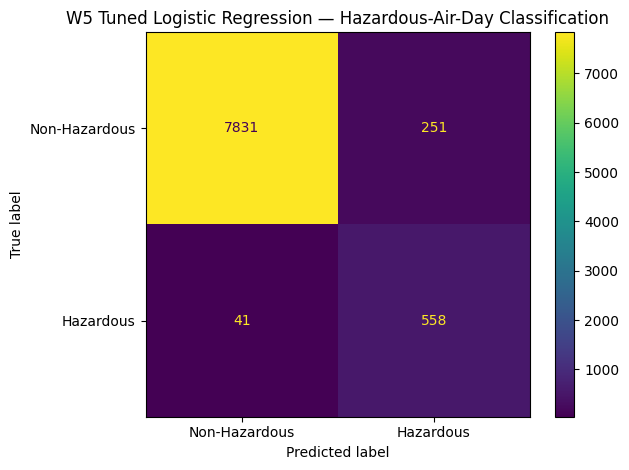

W5 confusion matrix saved successfully.


In [62]:
# ============================================================
# W5 CELL 57 — FINAL TUNED CONFUSION MATRIX
# ============================================================

final_cm = confusion_matrix(
    test_fe_imp["Hazardous_Tomorrow"],
    y_pred_final_cls
)

print("=" * 70)
print("W5 FINAL TUNED CONFUSION MATRIX")
print("=" * 70)

print(final_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=[
        "Non-Hazardous",
        "Hazardous"
    ]
)

disp.plot()

plt.title(
    "W5 Tuned Logistic Regression — Hazardous-Air-Day Classification"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w5_final_logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("W5 confusion matrix saved successfully.")

In [63]:
# ============================================================
# W5 CELL 58 — FINAL TUNED REGRESSION COMPARISON
# ============================================================

final_tuned_regression = pd.DataFrame({
    "Model": [
        "W4 Engineered Lasso",
        "W5 Tuned Ridge — 1-SE",
        "W5 Tuned Lasso — 1-SE"
    ],
    "Alpha": [
        0.01,
        ridge_alpha_1se,
        lasso_alpha_1se
    ],
    "MAE": [
        lasso_fe_mae,
        final_ridge_mae,
        final_lasso_mae
    ],
    "RMSE": [
        lasso_fe_rmse,
        final_ridge_rmse,
        final_lasso_rmse
    ],
    "R2": [
        lasso_fe_r2,
        final_ridge_r2,
        final_lasso_r2
    ]
})

print("=" * 70)
print("W5 FINAL TUNED REGRESSION COMPARISON")
print("=" * 70)

display(final_tuned_regression)

W5 FINAL TUNED REGRESSION COMPARISON


,Model,Alpha,MAE,RMSE,R2
0,W4 Engineered Lasso,0.01,22.128465,40.715327,0.845250
1,W5 Tuned Ridge — 1-SE,100.00,22.134196,40.713274,0.845266
2,W5 Tuned Lasso — 1-SE,1.00,21.903789,40.382361,0.847771


In [64]:
# ============================================================
# W5 CELL 59 — SAVE FINAL REGRESSION RESULTS
# ============================================================

final_tuned_regression.to_csv(
    "../graphs/w5_final_regression_comparison.csv",
    index=False
)

print("Final W5 regression comparison saved successfully.")

Final W5 regression comparison saved successfully.


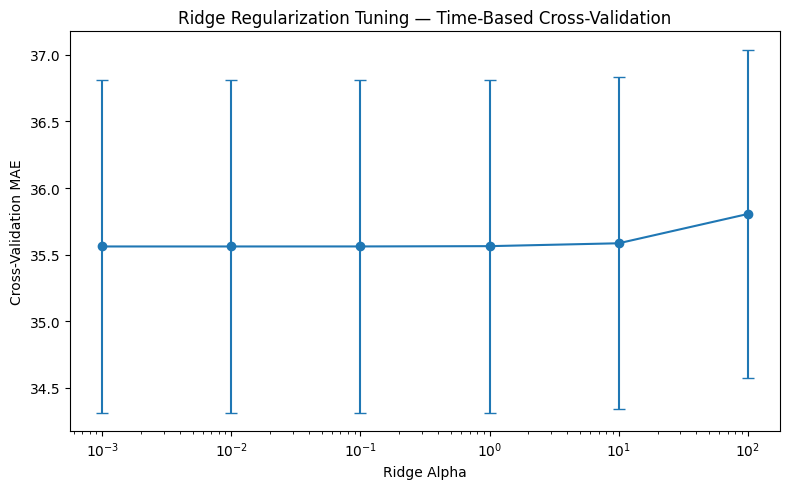

Ridge CV graph saved successfully.


In [65]:
# ============================================================
# W5 CELL 60 — RIDGE CV PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    ridge_cv_results["Alpha"],
    ridge_cv_results["Mean_MAE"],
    yerr=ridge_cv_results["SE_MAE"],
    marker="o",
    capsize=4
)

plt.xscale("log")

plt.xlabel("Ridge Alpha")
plt.ylabel("Cross-Validation MAE")

plt.title(
    "Ridge Regularization Tuning — Time-Based Cross-Validation"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w5_ridge_cv_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Ridge CV graph saved successfully.")

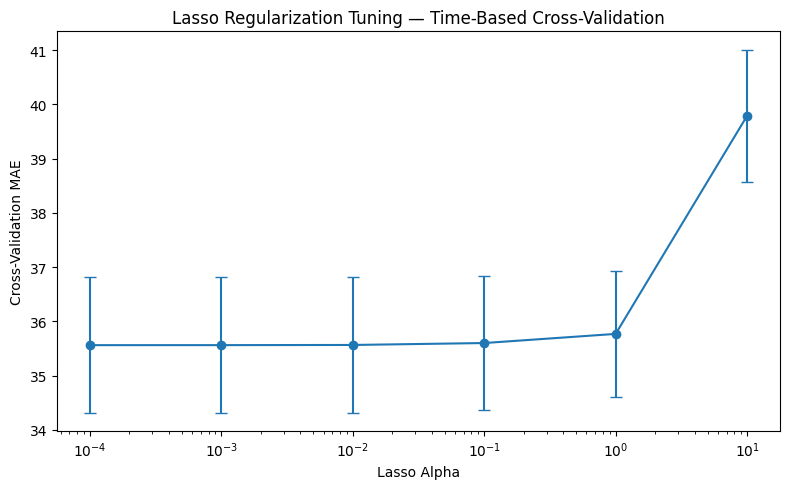

Lasso CV graph saved successfully.


In [66]:
# ============================================================
# W5 CELL 61 — LASSO CV PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    lasso_cv_results["Alpha"],
    lasso_cv_results["Mean_MAE"],
    yerr=lasso_cv_results["SE_MAE"],
    marker="o",
    capsize=4
)

plt.xscale("log")

plt.xlabel("Lasso Alpha")
plt.ylabel("Cross-Validation MAE")

plt.title(
    "Lasso Regularization Tuning — Time-Based Cross-Validation"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w5_lasso_cv_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Lasso CV graph saved successfully.")

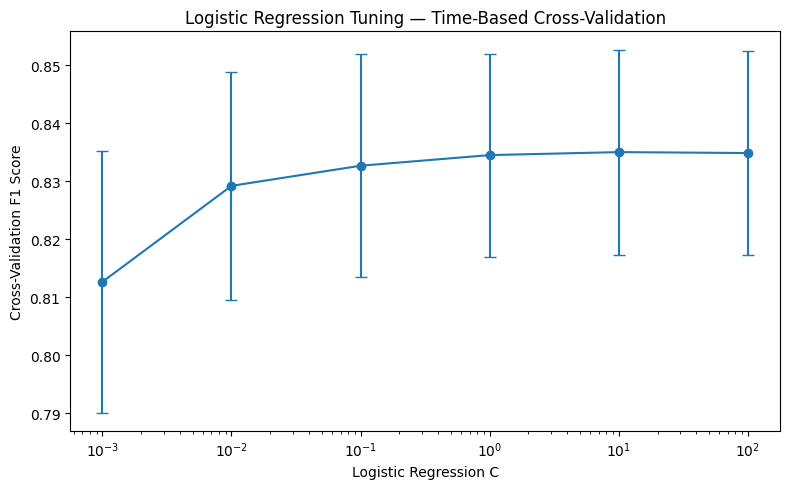

Logistic CV graph saved successfully.


In [67]:
# ============================================================
# W5 CELL 62 — LOGISTIC CV PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    logistic_cv_results["C"],
    logistic_cv_results["Mean_F1"],
    yerr=logistic_cv_results["SE_F1"],
    marker="o",
    capsize=4
)

plt.xscale("log")

plt.xlabel("Logistic Regression C")
plt.ylabel("Cross-Validation F1 Score")

plt.title(
    "Logistic Regression Tuning — Time-Based Cross-Validation"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w5_logistic_cv_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Logistic CV graph saved successfully.")

In [68]:
# ============================================================
# W5 CELL 63 — FINAL AEROPURE W5 SUMMARY
# ============================================================

print("=" * 75)
print("AEROPURE — WEEK 5 FINAL SUMMARY")
print("=" * 75)

print("\nREGRESSION")
print("-" * 75)

print(
    f"Best Ridge 1-SE alpha : {ridge_alpha_1se}"
)

print(
    f"Ridge MAE             : {final_ridge_mae:.4f}"
)

print(
    f"Ridge RMSE            : {final_ridge_rmse:.4f}"
)

print(
    f"Ridge R²              : {final_ridge_r2:.4f}"
)

print()

print(
    f"Best Lasso 1-SE alpha : {lasso_alpha_1se}"
)

print(
    f"Lasso MAE             : {final_lasso_mae:.4f}"
)

print(
    f"Lasso RMSE            : {final_lasso_rmse:.4f}"
)

print(
    f"Lasso R²              : {final_lasso_r2:.4f}"
)


print("\nCLASSIFICATION")
print("-" * 75)

print(
    f"Best Logistic C       : {logistic_C_1se}"
)

print(
    f"Accuracy              : {final_accuracy:.4f}"
)

print(
    f"Precision             : {final_precision:.4f}"
)

print(
    f"Recall                : {final_recall:.4f}"
)

print(
    f"F1 Score              : {final_f1:.4f}"
)

print(
    f"ROC-AUC               : {final_roc_auc:.4f}"
)

print("\n" + "=" * 75)
print("W5 COMPLETE")
print("=" * 75)

AEROPURE — WEEK 5 FINAL SUMMARY

REGRESSION
---------------------------------------------------------------------------
Best Ridge 1-SE alpha : 100.0
Ridge MAE             : 22.1342
Ridge RMSE            : 40.7133
Ridge R²              : 0.8453

Best Lasso 1-SE alpha : 1.0
Lasso MAE             : 21.9038
Lasso RMSE            : 40.3824
Lasso R²              : 0.8478

CLASSIFICATION
---------------------------------------------------------------------------
Best Logistic C       : 0.01
Accuracy              : 0.9664
Precision             : 0.6897
Recall                : 0.9316
F1 Score              : 0.7926
ROC-AUC               : 0.9896

W5 COMPLETE


In [69]:
# ============================================================
# W5 CELL 64 — SAVE COMPLETE W5 SUMMARY
# ============================================================

w5_summary = pd.DataFrame({
    "Model": [
        "Tuned Ridge — 1-SE",
        "Tuned Lasso — 1-SE",
        "Tuned Logistic — 1-SE"
    ],
    "Hyperparameter": [
        ridge_alpha_1se,
        lasso_alpha_1se,
        logistic_C_1se
    ],
    "MAE": [
        final_ridge_mae,
        final_lasso_mae,
        np.nan
    ],
    "RMSE": [
        final_ridge_rmse,
        final_lasso_rmse,
        np.nan
    ],
    "R2": [
        final_ridge_r2,
        final_lasso_r2,
        np.nan
    ],
    "Accuracy": [
        np.nan,
        np.nan,
        final_accuracy
    ],
    "Precision": [
        np.nan,
        np.nan,
        final_precision
    ],
    "Recall": [
        np.nan,
        np.nan,
        final_recall
    ],
    "F1": [
        np.nan,
        np.nan,
        final_f1
    ],
    "ROC_AUC": [
        np.nan,
        np.nan,
        final_roc_auc
    ]
})

display(w5_summary)

w5_summary.to_csv(
    "../graphs/w5_complete_summary.csv",
    index=False
)

print("Complete W5 summary saved successfully.")

,Model,Hyperparameter,MAE,RMSE,R2,Accuracy,Precision,Recall,F1,ROC_AUC
0,Tuned Ridge — 1-SE,100.00,22.134196,40.713274,0.845266,NaN,NaN,NaN,NaN,NaN
1,Tuned Lasso — 1-SE,1.00,21.903789,40.382361,0.847771,NaN,NaN,NaN,NaN,NaN
2,Tuned Logistic — 1-SE,0.01,NaN,NaN,NaN,0.966363,0.68974,0.931553,0.792614,0.98963


Complete W5 summary saved successfully.


In [ ]:
# ============================================================
# W5 CELL 65 — MASTER MODEL RESULTS
# ============================================================

master_results = pd.DataFrame({
    "Model": [
        "W3 OLS",
        "W3 Gradient Descent",
        "W4 Lasso - 11 Features",
        "W4 Engineered Ridge - 16 Features",
        "W4 Engineered Lasso - 16 Features",
        "W5 Tuned Ridge - 1SE",
        "W5 Tuned Lasso - 1SE",
        "W4 Logistic Regression",
        "W5 Tuned Logistic - 1SE"
    ],

    "MAE": [
        ols_mae_w4,
        gd_mae,
        lasso_mae,
        ridge_fe_mae,
        lasso_fe_mae,
        final_ridge_mae,
        final_lasso_mae,
        np.nan,
        np.nan
    ],

    "RMSE": [
        ols_rmse_w4,
        gd_rmse,
        lasso_rmse,
        ridge_fe_rmse,
        lasso_fe_rmse,
        final_ridge_rmse,
        final_lasso_rmse,
        np.nan,
        np.nan
    ],

    "R2": [
        ols_r2_w4,
        gd_r2,
        lasso_r2,
        ridge_fe_r2,
        lasso_fe_r2,
        final_ridge_r2,
        final_lasso_r2,
        np.nan,
        np.nan
    ],

    "Accuracy": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        accuracy,
        final_accuracy
    ],

    "Precision": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        precision,
        final_precision
    ],

    "Recall": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        recall,
        final_recall
    ],

    "F1": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        f1,
        final_f1
    ],

    "ROC_AUC": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        roc_auc,
        final_roc_auc
    ]
})

print("=" * 75)
print("AEROPURE — MASTER MODEL RESULTS")
print("=" * 75)

display(master_results)

master_results.to_csv(
    "../graphs/aeropure_master_model_results.csv",
    index=False
)

print("\nMaster results saved successfully.")